In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [233]:
warnings.filterwarnings('ignore')

In [234]:
df = pd.read_csv('/content/student_performance.csv')

In [235]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [237]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].replace({'Yes': 1, 'No': 0})

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [239]:
df.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [240]:
df['Hours Studied'] = df['Hours Studied'].astype(np.uint8)
df['Previous Scores'] = df['Previous Scores'].astype(np.uint8)
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype(np.uint8)
df['Sleep Hours'] = df['Sleep Hours'].astype(np.uint8)
df['Sample Question Papers Practiced'] = df['Sample Question Papers Practiced'].astype(np.uint8)
df['Performance Index'] = df['Performance Index'].astype(np.float16)

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  uint8  
 1   Previous Scores                   10000 non-null  uint8  
 2   Extracurricular Activities        10000 non-null  uint8  
 3   Sleep Hours                       10000 non-null  uint8  
 4   Sample Question Papers Practiced  10000 non-null  uint8  
 5   Performance Index                 10000 non-null  float16
dtypes: float16(1), uint8(5)
memory usage: 68.5 KB


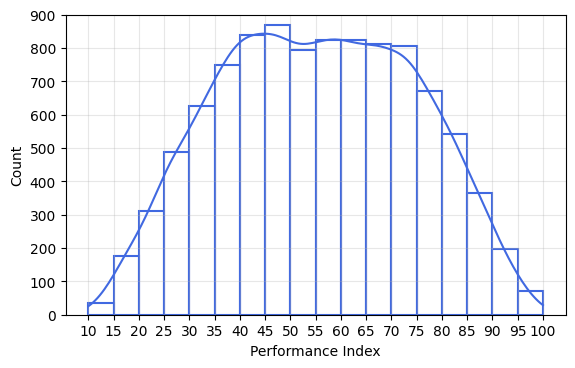

In [242]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.set_ylim(0, 900)
axes.set_xticks(np.arange(0, 101, 5))

sns.histplot(df['Performance Index'], binwidth = 5, kde = True, fill = False, color = 'royalblue')

axes.grid(alpha = 0.3)

plt.show()

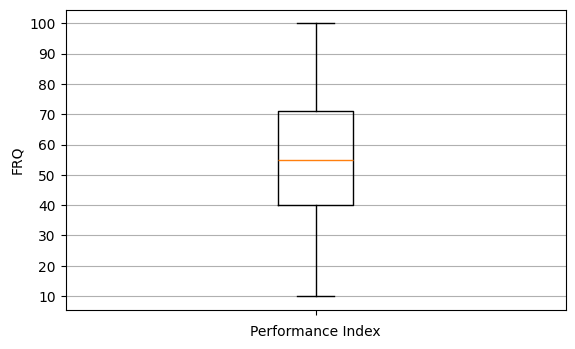

In [243]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.boxplot(df['Performance Index'])

axes.set_xlabel('Performance Index')
axes.set_ylabel('FRQ')

axes.xaxis.set_ticklabels([])
axes.yaxis.set_ticks(np.arange(10, 101, 10))

axes.grid(axis = 'y')

plt.show()

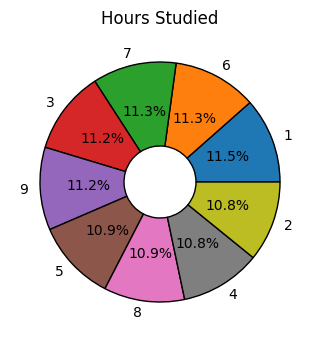

In [244]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_hours_studied = df['Hours Studied'].value_counts()

axes.pie(df_count_hours_studied,
         labels = df_count_hours_studied.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.7},
         autopct = '%1.1f%%'
         )

axes.set_title('Hours Studied')

plt.show()

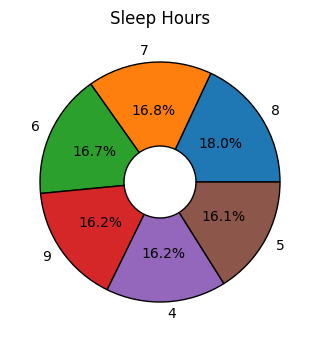

In [245]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_sleep_hours = df['Sleep Hours'].value_counts()

axes.pie(df_count_sleep_hours,
         labels = df_count_sleep_hours.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.7},
         autopct = '%1.1f%%'
         )

axes.set_title('Sleep Hours')

plt.show()

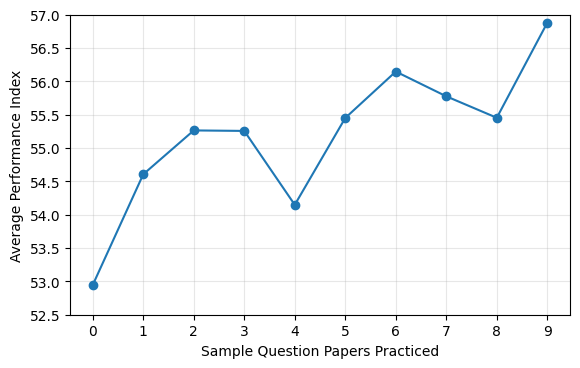

In [246]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_question_practiced	= df.groupby('Sample Question Papers Practiced')['Performance Index'].mean()

axes.plot(average_performance_by_question_practiced.index,
          average_performance_by_question_practiced,
          marker = 'o'
          )

axes.set_ylim(52.5, 57)

axes.set_xlabel('Sample Question Papers Practiced')
axes.set_ylabel('Average Performance Index')

axes.xaxis.set_ticks(np.arange(0, 10, 1))

axes.grid(alpha = 0.3)

plt.show()

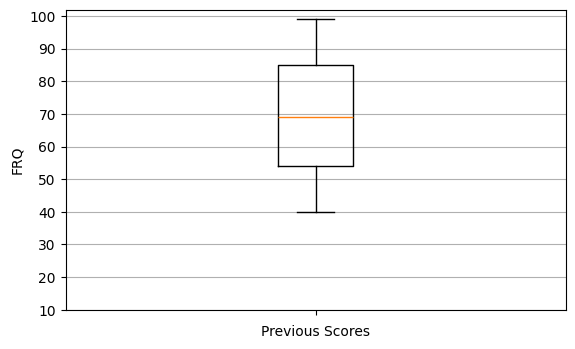

In [247]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.boxplot(df['Previous Scores'])

axes.set_xlabel('Previous Scores')
axes.set_ylabel('FRQ')

axes.xaxis.set_ticklabels([])
axes.yaxis.set_ticks(np.arange(10, 101, 10))

axes.grid(axis = 'y')

plt.show()

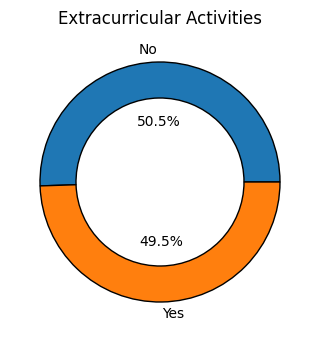

In [248]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_extracurricular_activities = df['Extracurricular Activities'].value_counts()

axes.pie(df_count_extracurricular_activities,
         labels = ['No', 'Yes'],
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.5
         )

axes.set_title('Extracurricular Activities')

plt.show()

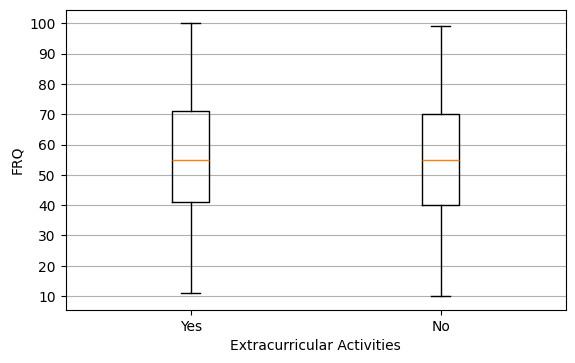

In [249]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

data_dictionary = {
    'Yes': df[df['Extracurricular Activities'] == 1]['Performance Index'],
    'No': df[df['Extracurricular Activities'] == 0]['Performance Index']
}

axes.boxplot(data_dictionary.values(), tick_labels = data_dictionary.keys())

axes.set_xlabel('Extracurricular Activities')
axes.set_ylabel('FRQ')

axes.yaxis.set_ticks(np.arange(10, 101, 10))

axes.grid(axis = 'y')

plt.show()

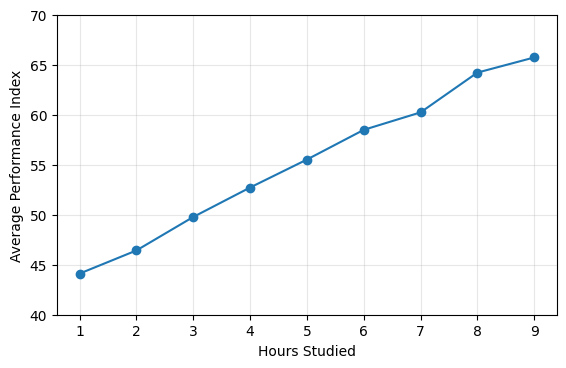

In [250]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_hours_studied = df.groupby('Hours Studied')['Performance Index'].mean()


axes.plot(average_performance_by_hours_studied.index,
          average_performance_by_hours_studied,
          marker = 'o'
          )

axes.set_ylim(40, 70)

axes.set_xlabel('Hours Studied')
axes.set_ylabel('Average Performance Index')

axes.grid(alpha = 0.3)

plt.show()

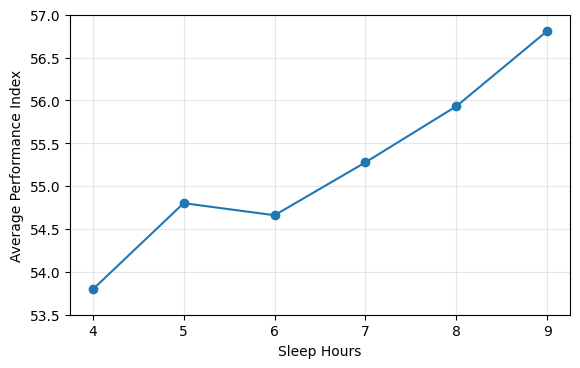

In [251]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_sleep_hours = df.groupby('Sleep Hours')['Performance Index'].mean()

axes.plot(average_performance_by_sleep_hours.index,
          average_performance_by_sleep_hours,
          marker = 'o'
          )

axes.set_ylim(53.5, 57)

axes.set_xlabel('Sleep Hours')
axes.set_ylabel('Average Performance Index')

axes.grid(alpha = 0.3)

plt.show()

In [252]:
df.drop_duplicates(keep = 'first', inplace = True)

<Axes: >

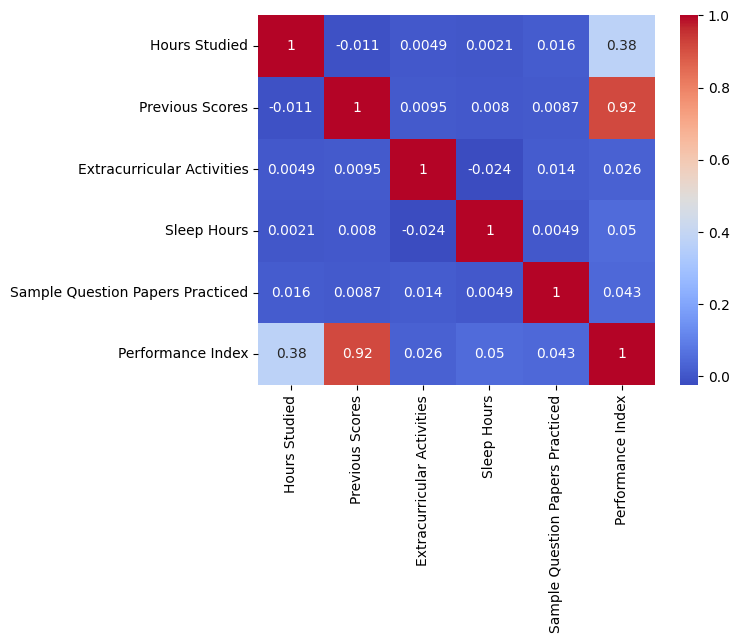

In [253]:
df_heat = df.corr()
sns.heatmap(df_heat, annot = True, cmap = 'coolwarm')

In [254]:
X = df.drop(['Performance Index'], axis = 1)

In [255]:
y = df['Performance Index']

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 10)

In [257]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [258]:
model.score(X_train, y_train)

0.9888956710625104

In [259]:
prediction = np.round(model.predict(X_test))

In [260]:
df_result = pd.DataFrame({'Actual Performance': y_test, 'Predicted Performance': prediction})

In [261]:
df_result.head()

,Actual Performance,Predicted Performance
6488,74.0,76.0
3427,50.0,56.0
8382,72.0,72.0
1553,40.0,38.0
3921,30.0,30.0


In [262]:
df_result.tail()

,Actual Performance,Predicted Performance
9660,41.0,38.0
1702,31.0,32.0
6073,19.0,20.0
2727,48.0,49.0
2201,86.0,84.0


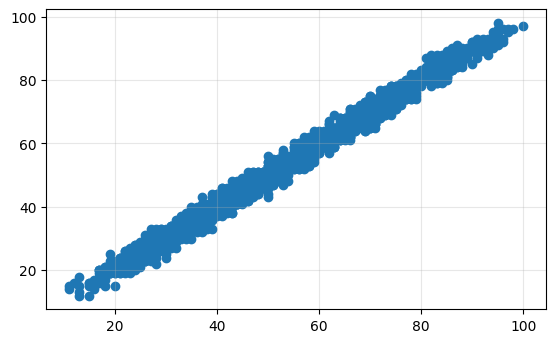

In [265]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.scatter(y_test, prediction)

axes.grid(alpha = 0.3)

plt.show()

In [267]:
mean_squared_error(y_test, prediction)

4.425316455696202

In [269]:
mean_absolute_error(y_test, prediction)

1.6232911392405063

In [270]:
mean_absolute_percentage_error(y_test, prediction)

0.034570345066582776

In [271]:
r2_score(y_test, prediction)

0.9876558857497637

In [272]:
model.coef_

array([2.85391567, 1.01802924, 0.59778371, 0.48258993, 0.18539982])

In [273]:
model.intercept_

np.float64(-34.03141143389313)